# Лабораторная работа №1
## Низкоуровневый анализ, предобработка текста и статистическое языковое моделирование

In [1]:
import os
import re
import html
import math
import time
import random
import gc
from collections import Counter, defaultdict
from itertools import chain
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_DIR = "data"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 300)
pd.set_option("display.width", 160)

### Шаг 1. Загрузка датасета

Загрузим датасет для дальнейшей работы

In [5]:
path = kagglehub.dataset_download("yasserh/amazon-product-reviews-dataset", force_download=True)
print("Path to dataset files:", path)

100%|██████████| 708k/708k [00:00<00:00, 1.17MB/s]

Extracting files...
Path to dataset files: C:\Users\sonyb\.cache\kagglehub\datasets\yasserh\amazon-product-reviews-dataset\versions\1


In [6]:
df = pd.read_csv(os.path.join(path, "7817_1.csv"))
print(df.shape)

(1597, 27)


Прежде чем отбирать колонки, осмотрим сырой датасет

In [7]:
print("Строк:", len(df), "| Колонок:", df.shape[1])

# пропуски по колонкам
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print(f"Колонок с пропусками: {len(na)} из {df.shape[1]}")
display(na.to_frame("Пропусков"))

# полностью пустые колонки не несут никакой информации
empty_cols = na[na == len(df)].index.tolist()
print("Полностью пустые колонки:", empty_cols)

# дубликаты: полные строки и повторяющиеся тексты отзывов
print("Полных дубликатов строк:    ", int(df.duplicated().sum()))
print("Дубликатов по reviews.text: ", int(df.duplicated(subset=["reviews.text"]).sum()),
      f"(уникальных текстов: {df['reviews.text'].nunique()} из {len(df)})")


Строк: 1597 | Колонок: 27
Колонок с пропусками: 16 из 27


,Пропусков
reviews.userCity,1597
reviews.userProvince,1597
sizes,1597
reviews.doRecommend,1058
dimension,1032
weight,911
colors,823
ean,699
upc,699
reviews.numHelpful,697


Полностью пустые колонки: ['reviews.userCity', 'reviews.userProvince', 'sizes']
Полных дубликатов строк:     0
Дубликатов по reviews.text:  549 (уникальных текстов: 1048 из 1597)


In [8]:
# ключевые колонки для первичного взгляда (полный текст укорочен для читаемости)
peek_cols = ["reviews.text", "reviews.rating", "reviews.title", "reviews.date", "reviews.username"]
peek = df[peek_cols].head(3).copy()
peek["reviews.text"] = peek["reviews.text"].str.slice(0, 120) + "..."
display(peek)

,reviews.text,reviews.rating,reviews.title,reviews.date,reviews.username
0,I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing:...,5.0,"Paperwhite voyage, no regrets!",2015-08-08T00:00:00.000Z,Cristina M
1,Allow me to preface this with a little history. I am (was) a casual reader who owned a Nook Simple Touch from 2011. I've...,5.0,One Simply Could Not Ask For More,2015-09-01T00:00:00.000Z,Ricky
2,I am enjoying it so far. Great for reading. Had the original Fire since 2012. The Fire used to make my eyes hurt if I re...,4.0,Great for those that just want an e-reader,2015-07-20T00:00:00.000Z,Tedd Gardiner


Осмотр сырого датасета: 1 597 строк × 27 колонок. Целевая колонка `reviews.text`заполнена полностью, а вот у `reviews.rating` 420 пропусков (~26% строк) - отзывы без оценки не годятся для стратификации, поэтому дальше такие строки отбрасываются. Три колонки полностью пусты (`reviews.userCity`, `reviews.userProvince`, `sizes`) и не несут информации. Полных дубликатов строк нет, но сами тексты отзывов повторяются. Уникальных текстов 1 048 из 1 597, то есть 549 повторов. С повторами нужно разобраться до разбиения на train/test, иначе один и тот же отзыв попадёт в обе выборки - это утечка данных.


В датасете 27 колонок, но нам нужны две:
- reviews.text - целевая текстовая колонка
- reviews.rating - целевой класс (для стратификации)

In [9]:
df = df[["reviews.text", "reviews.rating"]].rename(
    columns={"reviews.text": "Text", "reviews.rating": "Score"}
)

df = df.dropna(subset=["Text", "Score"]).copy()
df["Text"] = df["Text"].astype(str)
df["Score"] = df["Score"].astype(int)

print(df.shape)

(1177, 2)


In [10]:
print(df["Score"].value_counts().sort_index())

Score
1     42
2     34
3    124
4    236
5    741
Name: count, dtype: int64


Наглядно посмотрим на то же распределение: классы резко несбалансированы, что и
обусловливает стратификацию при разбиении.

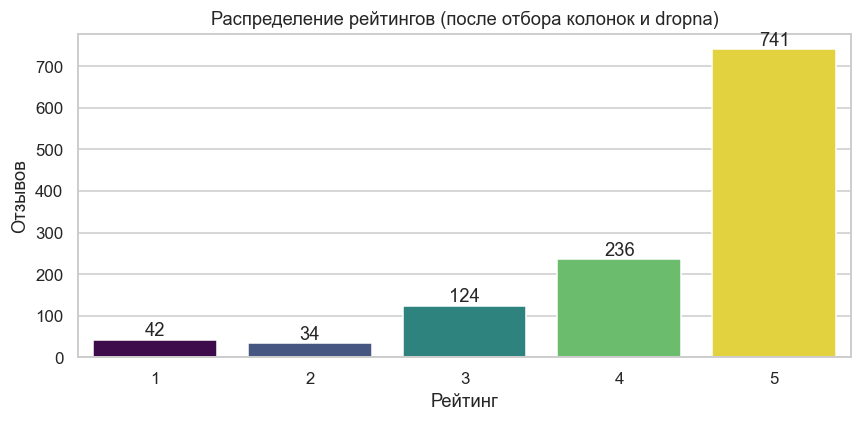

In [11]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="Score", hue="Score", palette="viridis", legend=False)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Распределение рейтингов (после отбора колонок и dropna)")
plt.xlabel("Рейтинг")
plt.ylabel("Отзывов")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "rating_distribution.png"), bbox_inches="tight")
plt.show()

Пятёрочных отзывов 741 - почти в 18 раз больше, чем единичных (42). Классы 1–3 вместе составляют около 17% данных. Без стратификации при таком перекосе доли редких классов в train и test могли бы заметно разъехаться, поэтому разбиение выполняется по `Score`.

Нужно теперь убрать дубликаты текста до разделения. Иначе один и тот же отзыв попадёт и в train, и в test и это станет утечкой данных.

In [12]:
before = len(df)
df = df.drop_duplicates(subset=["Text"]).reset_index(drop=True)
print(f"{before} -> {len(df)}")

1177 -> 908


In [13]:
train, test = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df["Score"])
print("train:", train.shape, "test:", test.shape)

train: (726, 2) test: (182, 2)


In [14]:
print("train, доли классов:")
print(train["Score"].value_counts(normalize=True).sort_index().round(3))

print("\ntest, доли классов:")
print(test["Score"].value_counts(normalize=True).sort_index().round(3))

train, доли классов:
Score
1    0.045
2    0.034
3    0.077
4    0.220
5    0.623
Name: proportion, dtype: float64

test, доли классов:
Score
1    0.044
2    0.033
3    0.077
4    0.220
5    0.626
Name: proportion, dtype: float64


Доли классов в train и test совпадают - стратификация сработала. Датасет сильно
несбалансирован (скор 5 ≈ 62%), но это свойство самих данных, а не ошибка разделения

### Шаг 2. Анализ структуры обучающей выборки

In [15]:
train["n_words"] = train["Text"].str.split().str.len()
train["n_chars"] = train["Text"].str.len()

In [16]:
print("Документов в train:", len(train))
print("Всего слов:", int(train["n_words"].sum()))
print("Средняя длина в словах:", round(train["n_words"].mean(), 2))
print("Средняя длина в символах:", round(train["n_chars"].mean(), 2))
print()
print(train["n_words"].describe().round(2))

Документов в train: 726
Всего слов: 77638
Средняя длина в словах: 106.94
Средняя длина в символах: 577.42

count     726.00
mean      106.94
std       257.67
min         1.00
25%        18.00
50%        38.50
75%        96.75
max      3601.00
Name: n_words, dtype: float64


Посмотрим распределение длин и топ-30 стоп-слов на графиках

In [17]:
p99w = train["n_words"].quantile(0.99)
p99c = train["n_chars"].quantile(0.99)

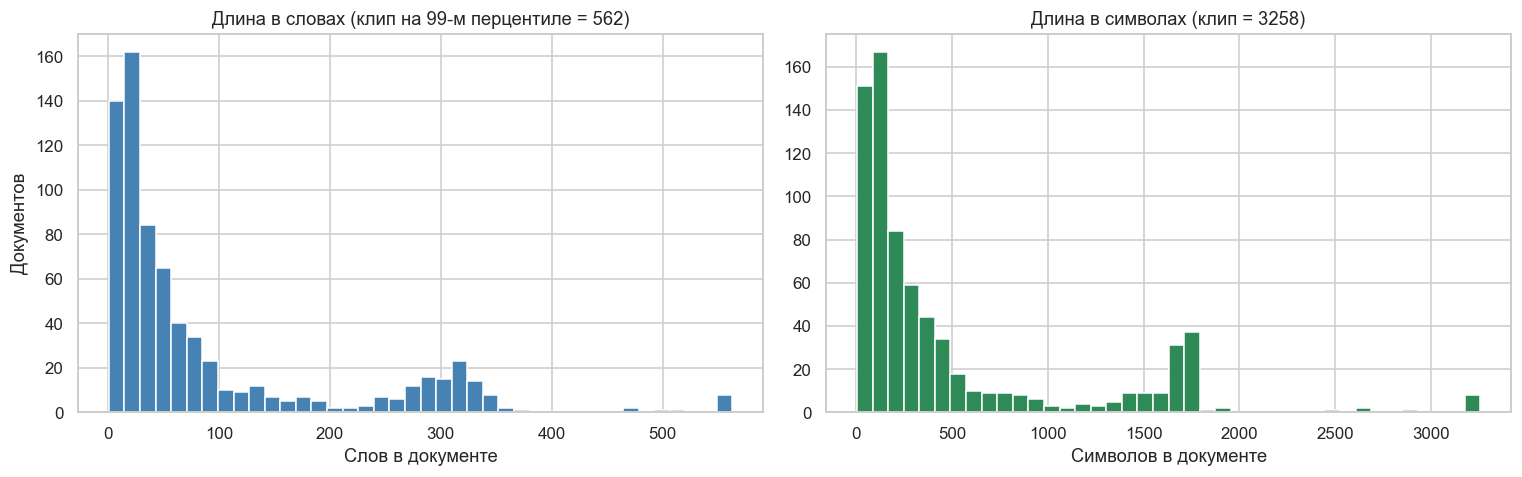

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(train["n_words"].clip(upper=p99w), bins=40, color="steelblue")
axes[0].set_title(f"Длина в словах (клип на 99-м перцентиле = {p99w:.0f})")
axes[0].set_xlabel("Слов в документе")
axes[0].set_ylabel("Документов")
axes[1].hist(train["n_chars"].clip(upper=p99c), bins=40, color="seagreen")
axes[1].set_title(f"Длина в символах (клип = {p99c:.0f})")
axes[1].set_xlabel("Символов в документе")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "length_distributions.png"), bbox_inches="tight")
plt.show()

Большинство отзывов короткие (медиана ≈ 38 слов), но есть отдельные длинные эссе. Распределение длин имеет выраженный правый хвост.

In [19]:
import nltk
from collections import Counter
from itertools import chain
from nltk.corpus import stopwords

In [20]:
nltk.download("stopwords", quiet=True)
STOP_EN = set(stopwords.words("english"))

Токенизируем только буквы (нижний регистр, NLTK-стоп-слова в нижнем регистре)

In [21]:
tokens = train["Text"].astype(str).str.lower().str.findall(r"[a-z']+")
token_counter = Counter(chain.from_iterable(tokens))

In [22]:
stop_freq = Counter({w: token_counter[w] for w in STOP_EN if token_counter[w] > 0})
top30 = stop_freq.most_common(30)

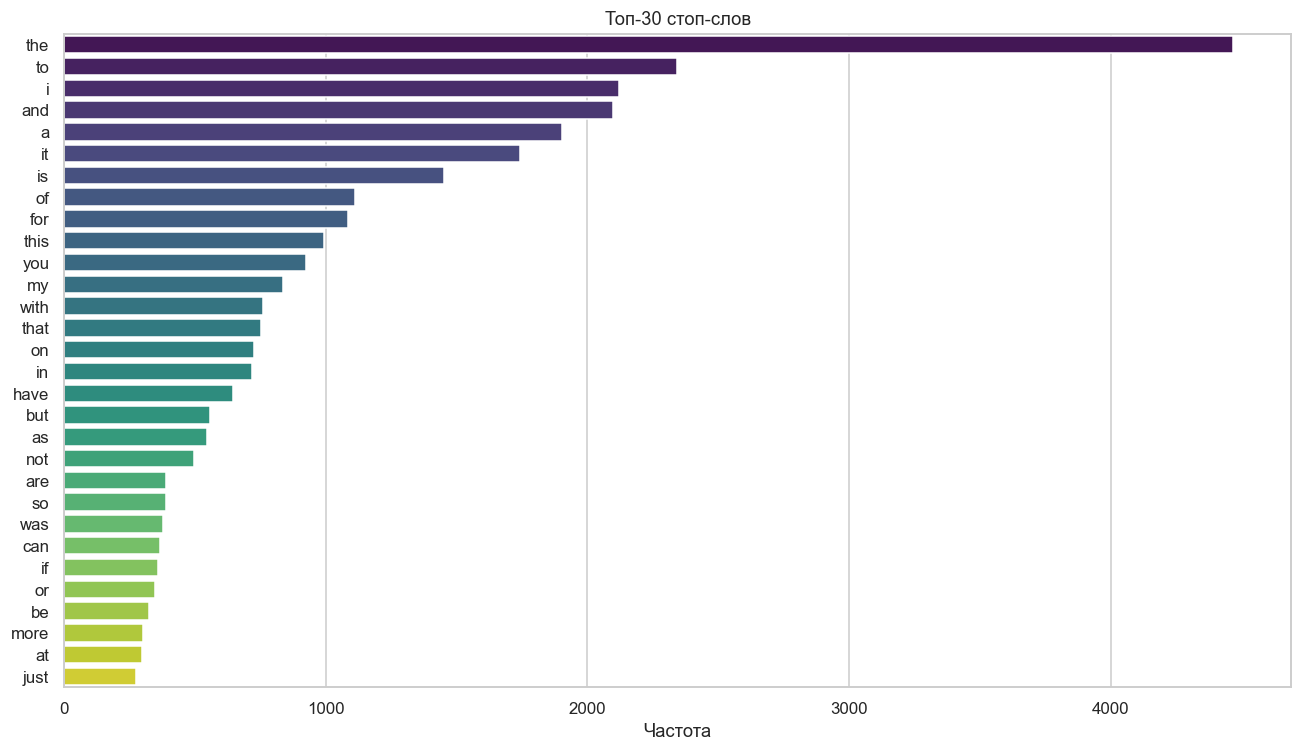

In [23]:
plt.figure(figsize=(12, 7))
words, counts = zip(*top30)
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="viridis", legend=False)
plt.title("Топ-30 стоп-слов")
plt.xlabel("Частота")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "top30_stopwords.png"), bbox_inches="tight")
plt.show()

Топ-30 стоп-слов ожидаемо занимают служебные части речи (the, and, to, a, i, it, is …), что подтверждает необходимость их учёта на этапе нормализации.

### Шаг 3. Типы специфического шума

In [24]:
NOISE_PATTERNS = {
    "HTML-теги": r"<[^>]+>",
    "HTML-сущности": r"&[a-zA-Z#0-9]+;",
    "Битый HTML (атрибуты)": r"\b(?:href|src|onclick|onmouseover|onmouseout)\S*",
    "URL-адреса": r"(?:https?://|www\.)\S+",
    "E-mail": r"\b[\w.%+-]+@[\w.-]+\.[A-Za-z]{2,}\b",
    "Упоминания @user": r"@\w+",
    "Хэштеги": r"#\w+",
    "Числа": r"\b\d+\b",
    "Цены (валюта)": r"[$€£]\s?\d",
    "Повторная пунктуация": r"[!?.,;:]{2,}",
    "Слова CAPS": r"\b[A-Z]{3,}\b",
    "Не-ASCII символы": r"[^\x00-\x7F]",
    "Эмодзи": r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
    "Невидимые (zero-width)": r"[\u200b-\u200f\u2028-\u202f\ufeff]",
    "Табы / кратные пробелы": r"\t| {2,}",
}

Проанализируем шум по всему размеченному корпусу (`df`, а не только train). 

Профиль шума нужен, чтобы спроектировать правила очистки, при этом сами правила пишутся вручную и никакая статистика из test в модель не попадает - утечки данных нет. Все последующие шаги (словарь, счётчики N-грамм, генерация) строятся строго по train.


In [25]:
texts_all = df["Text"].astype(str)
rows = []
for name, pat in NOISE_PATTERNS.items():
    # bool-маска, где встречается
    mask = texts_all.str.contains(pat, regex=True)
    rows.append({
        "Тип шума": name,
        "Документов": int(mask.sum()),          
        "Доля, %": round(float(mask.mean()) * 100, 2), 
    })

In [26]:
noise_df = (pd.DataFrame(rows).sort_values("Доля, %", ascending=False).reset_index(drop=True))
display(noise_df.style.hide(axis="index").background_gradient(subset=["Доля, %"], cmap="Reds"))

Тип шума,Документов,"Доля, %"
Числа,247,27.200000
Слова CAPS,171,18.830000
Повторная пунктуация,129,14.210000
Цены (валюта),7,0.770000
URL-адреса,5,0.550000
Не-ASCII символы,2,0.220000
Битый HTML (атрибуты),1,0.110000
HTML-теги,0,0.000000
HTML-сущности,0,0.000000
E-mail,0,0.000000


Печатаем окно вокруг первого совпадения, а не начало текста. Шум часто стоит дальше 220 символов, и обрезка начала его просто прячет

In [27]:
print("=== Примеры найденного шума ===\n")
for name in ["Битый HTML (атрибуты)", "Не-ASCII символы", "URL-адреса", "Цены (валюта)", "Повторная пунктуация", "Слова CAPS", "Числа"]:
    rx = re.compile(NOISE_PATTERNS[name])
    examples = texts_all[texts_all.str.contains(NOISE_PATTERNS[name], regex=True)].head(2)
    print(f"--- {name} ---")
    for t in examples:
        m = rx.search(t)
        s, e = max(0, m.start() - 70), min(len(t), m.end() + 70)
        frag = m.group(0)[:80]
        cps = "  " + " ".join(f"U+{ord(c):04X}" for c in frag) if any(ord(c) > 127 for c in frag) else ""
        print(f"  • позиция {m.start()}: ...{t[s:e].replace(chr(10), ' ')}...")
        print(f"    совпадение: {frag!r}{cps}")
    print()

=== Примеры найденного шума ===

--- Битый HTML (атрибуты) ---
  • позиция 2: ...a hrefhttp://www.amazon.com/review/R205OAX284SIMieUTF8videoPreplay1 onClickreturn cvmoOTYXBAMRIF04loadSwf() targettopimg80 border0 srchtt...
    совпадение: 'hrefhttp://www.amazon.com/review/R205OAX284SIMieUTF8videoPreplay1'

--- Не-ASCII символы ---
  • позиция 221: ...oes work with the same "alexa" set up. The Echo operates with no hands…you can simply speak to Alexa. The tap has a microphone button you nee...
    совпадение: '…'  U+2026
  • позиция 221: ...oes work with the same "alexa" set up. The Echo operates with no hands���you can simply speak to Alexa. The tap has a microphone button you n...
    совпадение: '�'  U+FFFD

--- URL-адреса ---
  • позиция 6: ...a hrefhttp://www.amazon.com/review/R205OAX284SIMieUTF8videoPreplay1 onClickreturn cvmoOTYXBAMRIF04loadSwf() targettopimg80 border0 srchtt...
    совпадение: 'http://www.amazon.com/review/R205OAX284SIMieUTF8videoPreplay1'
  • позиция 1046: ... m

В корпусе выявлены следующие типы шума: числовые данные и номера моделей (27.2%), CAPS-слова - технические аббревиатуры и «крикливые» слова вроде HDX, USB, WIFI, NOT (18.8%), повторная пунктуация (14.2%), валютные суммы, URL-адреса и специфичный битый HTML - атрибуты тегов без угловых скобок, оставшиеся после парсинга. Ряд типов полностью отсутствует (HTML-теги, HTML-сущности, e-mail, упоминания, хэштеги, эмодзи, невидимые символы, табы), что доказано нулевыми счётчиками.

Датасет посвящён устройствам Amazon (Kindle, Fire, Echo), поэтому шум объясним предметной областью.

Числа - это разрешения экранов (1200x800, 1920x1200), названия моделей (HD 8) и характеристики вроде 300 ppi, а CAPS - обозначения линеек и интерфейсов (HDX, USB, WIFI, HDMI). 

Любопытная деталь... Оба «не-ASCII» примера - один и тот же отзыв в двух строках датасета, и различие на глаз не видно: в одной копии стоит многоточие U+2026, в другой - замещающий символ U+FFFD, возникший из-за повреждённой кодировки.

### Шаг 4. Конвейер очистки текста

Правила применяются каскадом. Запрещено «удалять всё, кроме букв»: числа, ссылки и прочие артефакты заменяются специальными токенами `[URL]`, `[EMAIL]`, `[USER]`, `[NUM]`, чтобы сохранить факт их присутствия для модели. В конце каждый документ оборачивается техническими токенами `<s>` и `</s>`.

In [28]:
# HTML-теги
RE_HTML_TAG      = re.compile(r"<[^>]+>")
# битый HTML
RE_HTML_ATTR     = re.compile(r"\b(?:href|src|onclick|onmouseover|onmouseout)\S*", re.I)
# фрагменты JS
RE_JS_CALL       = re.compile(r"\b\w+\(\)")
# URL
RE_URL           = re.compile(r"(?:https?://|www\.)\S+", re.I)
# e-mail
RE_EMAIL         = re.compile(r"\b[\w.%+-]+@[\w.-]+\.[A-Za-z]{2,}\b")
# @user
RE_MENTION       = re.compile(r"@\w+")
# #tag
RE_HASHTAG       = re.compile(r"#(\w+)")
# цены
RE_MONEY         = re.compile(r"[$€£]\s?\d+(?:[.,]\d+)?")
# числа
RE_NUM           = re.compile(r"\b\d+(?:[.,]\d+)*\b")
# ' '
RE_SMART_SINGLE  = re.compile(r"[\u2018\u2019]")
# “ ”
RE_SMART_DOUBLE  = re.compile(r"[\u201c\u201d]")
# – —
RE_DASH          = re.compile(r"[\u2013\u2014]")
# !!!! -> !
RE_REPEAT_PUNCT  = re.compile(r"([!?.,;:])\1+")
# пробелы
RE_WS            = re.compile(r"\s+")

In [29]:
def clean_text(text: str) -> str:
    # HTML-сущности (&quot; -> ")
    t = html.unescape(str(text))
    # нижний регистр
    t = t.lower()
    # HTML-теги
    t = RE_HTML_TAG.sub(" ", t)
    # битый HTML, атрибуты без скобок
    t = RE_HTML_ATTR.sub(" ", t)
    # фрагменты JS-вызовов
    t = RE_JS_CALL.sub(" ", t)
    # URL -> [URL]
    t = RE_URL.sub(" [URL] ", t)
    # email -> [EMAIL]
    t = RE_EMAIL.sub(" [EMAIL] ", t)
    # @user -> [USER]
    t = RE_MENTION.sub(" [USER] ", t)
    # #tag -> tag
    t = RE_HASHTAG.sub(r"\1", t)
    # цены -> [NUM]
    t = RE_MONEY.sub(" [NUM] ", t)
    # числа -> [NUM]
    t = RE_NUM.sub(" [NUM] ", t)
    # ‘ ’ -> '
    t = RE_SMART_SINGLE.sub("'", t)
    # “ ” -> "
    t = RE_SMART_DOUBLE.sub('"', t)
    # – — -> -
    t = RE_DASH.sub("-", t)
    # !!!! -> !
    t = RE_REPEAT_PUNCT.sub(r"\1", t)
    # схлопываем пробелы
    t = RE_WS.sub(" ", t).strip()
    
    return t

In [30]:
def wrap_sentence(text: str) -> str:
    return f"<s> {text} </s>"

Применим конвейер к train и test

In [31]:
train["clean"] = train["Text"].map(clean_text)
test["clean"]  = test["Text"].map(clean_text)
train["clean_tagged"] = train["clean"].map(wrap_sentence)
test["clean_tagged"]  = test["clean"].map(wrap_sentence)

In [32]:
print("=== Примеры до/после ===\n")
for i in range(3):
    print("ИСХОДНЫЙ :", train["Text"].iloc[i][:280].replace("\n", " "))
    print("ОЧИЩЕННЫЙ:", train["clean_tagged"].iloc[i][:280])
    print("-" * 100)

=== Примеры до/после ===

ИСХОДНЫЙ : Sounds great. Must touch to activate. Easy to use.
ОЧИЩЕННЫЙ: <s> sounds great. must touch to activate. easy to use. </s>
----------------------------------------------------------------------------------------------------
ИСХОДНЫЙ : This is my second fire and case. I love both even though I have not dropped my device I feel confident with the thick foam surrounding it would survive if I did.
ОЧИЩЕННЫЙ: <s> this is my second fire and case. i love both even though i have not dropped my device i feel confident with the thick foam surrounding it would survive if i did. </s>
----------------------------------------------------------------------------------------------------
ИСХОДНЫЙ : We bought to give away at a Halloween party. We own them ourselves and they are awesome
ОЧИЩЕННЫЙ: <s> we bought to give away at a halloween party. we own them ourselves and they are awesome </s>
-----------------------------------------------------------------------------

Проверим что шум ушел и токены на месте

In [33]:
RE_STANDALONE_NUM = re.compile(r"(?<!\w)\d+(?:[.,]\d+)*(?!\w)")

print("Отдельных чисел осталось: ", int(train["clean"].str.contains(RE_STANDALONE_NUM, regex=True).sum()))  # 0
print("Документов с цифрами внутри слов:", int(train["clean"].str.contains(r"\d", regex=True).sum()))       # 66
print("URL осталось:             ", int(train["clean"].str.contains(r"https?://|www\.", regex=True).sum()))
print("HTML-атрибутов осталось:  ", int(train["clean"].str.contains(r"\b(?:href|src|onclick)\S*", regex=True).sum()))
print("Начинаются с <s>:         ", bool(train["clean_tagged"].str.startswith("<s> ").all()))
print("Заканчиваются на </s>:    ", bool(train["clean_tagged"].str.endswith(" </s>").all()))

Отдельных чисел осталось:  0
Документов с цифрами внутри слов: 66
URL осталось:              0
HTML-атрибутов осталось:   0
Начинаются с <s>:          True
Заканчиваются на </s>:     True


### Шаг 5. Сравнительная нормализация. Стемминг и лемматизация

Посмотрим словарь уникальных токенов до нормализации

In [34]:
word_freq = Counter()
for c in train["clean"]:
    word_freq.update(c.split())

print("Уникальных токенов (до нормализации):", len(word_freq))
print("Всего токенов:", sum(word_freq.values()))

Уникальных токенов (до нормализации): 8423
Всего токенов: 78088


Теперь выполним стемминг и лемматизацию

In [35]:
import nltk
from nltk.stem import SnowballStemmer, WordNetLemmatizer

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [36]:
raw_vocab = list(word_freq.keys())

stemmer = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()

t0 = time.time()
stemmed_vocab = {stemmer.stem(w) for w in raw_vocab}
t_stem = time.time() - t0

t0 = time.time()
lemmatized_vocab = {lemmatizer.lemmatize(w) for w in raw_vocab}
t_lemma = time.time() - t0

print(f"Стемминг: {t_stem:.2f} с \nЛемматизация: {t_lemma:.2f} с")

Стемминг: 0.06 с 
Лемматизация: 2.65 с


Сравним размеры словарей

In [37]:
comparison = pd.DataFrame({
    "Метод": ["Без нормализации", "Стемминг (Snowball)", "Лемматизация (WordNet)"],
    "Уникальных токенов": [len(raw_vocab), len(stemmed_vocab), len(lemmatized_vocab)],
    "Время, с": [0.0, round(t_stem, 2), round(t_lemma, 2)],
})

In [38]:
comparison["Сокращение словаря, %"] = ((1 - comparison["Уникальных токенов"] / len(raw_vocab)) * 100).round(2)

In [39]:
display(comparison)

,Метод,Уникальных токенов,"Время, с","Сокращение словаря, %"
0,Без нормализации,8423,0.00,0.00
1,Стемминг (Snowball),7070,0.06,16.06
2,Лемматизация (WordNet),8021,2.65,4.77


In [40]:
demo = ["running", "runs", "ran", "better", "goods", "loved", "loving",
        "cities", "mice", "went", "purchased", "cheaply"]
display(pd.DataFrame({
    "Слово": demo,
    "Стемминг": [stemmer.stem(w) for w in demo],
    "Лемматизация": [lemmatizer.lemmatize(w) for w in demo],
}))

,Слово,Стемминг,Лемматизация
0,running,run,running
1,runs,run,run
2,ran,ran,ran
3,better,better,better
4,goods,good,good
5,loved,love,loved
6,loving,love,loving
7,cities,citi,city
8,mice,mice,mouse
9,went,went,went


Вывод по нормализации
- **Стемминг** сильнее сжимает словарь (агрессивно режет суффиксы), но даёт псевдоосновы (`cheaply -> cheapli`, `cities -> citi`), что повышает шум
- **Лемматизация** даёт осмысленные словарные формы, но сжимает словарь слабее, потому что WordNetLemmatizer по умолчанию работает без POS-тега (трактует слово как существительное).`running` не приводится к `run`. С POS-тегами качество было бы выше.
- Итоговое решение: сравнение выполнено в учебных целях, но итоговая модель строится на `train["clean"]` без стемминга и лемматизации. Словарь корпуса мал (8 423 токена), лемматизация без POS-тега сжимает его всего на 4.77% и часто оставляет словоформу без изменений, а стемминг искажает основы (`purchas`, `cheapli`) и ухудшил бы читаемость сгенерированных текстов. При росте корпуса или переходе к классификации лемматизация (лучше с POS-тегами) стала бы оправданной.


### Шаг 6. Поиск опечаток через строковые метрики

Реализуем расстояние Левенштейна с оптимизацией
по памяти. Храним только две строки матрицы (O(min(m, n)) вместо O(m·n)).

In [41]:
def levenshtein(a: str, b: str) -> int:
    """Расстояние редактирования (вставка/удаление/замена), память O(min(len(a), len(b)))"""
    # b делаем более короткой строкой
    if len(a) < len(b):          
        a, b = b, a

    # предыдущая строка матрицы: 0,1,2,...,len(b)
    prev = list(range(len(b) + 1))   

    for i, ca in enumerate(a, 1):
        curr = [i] + [0] * len(b)
        for j, cb in enumerate(b, 1):
            cost = 0 if ca == cb else 1
            curr[j] = min(
                # удаление
                prev[j] + 1,
                # вставка
                curr[j - 1] + 1,
                # замена
                prev[j - 1] + cost,   
            )
        # сдвигаем окно, текущая строка становится предыдущей
        prev = curr
        
    # правый нижний элемент = искомое расстояние
    return prev[-1]

Проверим на классических примерах

In [42]:
for x, y in [("kitten", "sitting"), ("flaw", "lawn"), ("", "abc"), ("abc", "abc"), ("deveops", "devops")]:
    print(f"lev({x!r}, {y!r}) = {levenshtein(x, y)}")

lev('kitten', 'sitting') = 3
lev('flaw', 'lawn') = 2
lev('', 'abc') = 3
lev('abc', 'abc') = 0
lev('deveops', 'devops') = 1


Чтобы не сравнивать все пары слов (O(V²)), строим индекс удалений (идея SymSpell)

Если слова на расстоянии ≤ 2, то после удаления из них до двух символов они совпадут. Индекс
даёт узкий набор кандидатов, для которых уже считается точное расстояние нашей функцией.

In [43]:
def deletion_variants(word: str, max_d: int = 2):
    """Все строки, получаемые удалением до max_d символов"""
    variants = {word}
    d1 = {word[:i] + word[i + 1:] for i in range(len(word))}
    variants |= d1
    if max_d >= 2:
        for v in d1:
            for i in range(len(v)):
                variants.add(v[:i] + v[i + 1:])
    return variants

Кандидаты только буквенные слова, не слишком короткие/длинные и не единичные

In [44]:
candidates = {w: c for w, c in word_freq.items() if w.isalpha() and 4 <= len(w) <= 15 and c >= 2}
print("Слов-кандидатов:", len(candidates))

Слов-кандидатов: 2268


In [45]:
index = defaultdict(list)
for w in candidates:
    for v in deletion_variants(w, 2):
        index[v].append(w)

In [46]:
pairs = set()
for v, ws in index.items():
    #  ограничиваем переполненные корзины
    if 1 < len(ws) <= 30:
        for i in range(len(ws)):
            for j in range(i + 1, len(ws)):
                a, b = ws[i], ws[j]
                pairs.add((a, b) if a < b else (b, a))

print("Кандидатных пар:", len(pairs))

Кандидатных пар: 17306


In [47]:
found = []
for a, b in pairs:
    d = levenshtein(a, b)
    if d in (1, 2):
        found.append((d, a, b, candidates[a], candidates[b]))

print("Пар с расстоянием 1 или 2:", len(found))

Пар с расстоянием 1 или 2: 8494


In [48]:
found_df = pd.DataFrame(found, columns=["Расст.", "Слово 1", "Слово 2", "Частота 1", "Частота 2"])
found_df["Мин. частота"] = found_df[["Частота 1", "Частота 2"]].min(axis=1)

In [49]:
top10 = (found_df.sort_values("Мин. частота", ascending=False).drop(columns="Мин. частота").head(10).reset_index(drop=True))
display(top10)

,Расст.,Слово 1,Слово 2,Частота 1,Частота 2
0,2,that,this,712,913
1,2,fire,more,370,283
2,2,fire,like,370,282
3,2,will,with,216,741
4,2,they,this,211,913
5,2,they,when,211,263
6,2,that,they,712,211
7,2,than,when,204,263
8,2,than,they,204,211
9,1,than,that,204,712


Топ-10 пар по минимальной частоте состоит из служебных слов: `that/this`, `will/with`, `than/that`. Формально это пары с расстоянием 1–2, но оба слова в них корректны - это не опечатки, а просто близкие по написанию легитимные слова, которые встречаются в корпусе чаще остальных. 

Чтобы отделить такие пары от настоящих опечаток, отфильтруем найденные пары по справочному словарю английских слов `nltk.corpus.words` и разложим их на три категории.

In [50]:
nltk.download("words", quiet=True)
from nltk.corpus import words as nltk_words

DICT_EN = {w.lower() for w in nltk_words.words()}
print("Размер справочного словаря NLTK:", f"{len(DICT_EN):,}")

# раскладываем найденные пары (расстояние 1-2) на три категории
both_known   = []   # оба слова словарные: легитимные похожие слова / формы одного слова
typo_cand    = []   # ровно одно словарное: главный кандидат в опечатки
both_unknown = []   # оба вне словаря: жаргон, шум, редкие токены корпуса

for d, a, b, fa, fb in found:
    ka, kb = a in DICT_EN, b in DICT_EN
    if ka and kb:
        both_known.append((d, a, b, fa, fb))
    elif ka or kb:
        typo_cand.append((d, a, b, fa, fb))
    else:
        both_unknown.append((d, a, b, fa, fb))

print(f"Оба слова в словаре:    {len(both_known):,} пар")
print(f"Одно слово в словаре:   {len(typo_cand):,} пар  <- кандидаты в опечатки")
print(f"Оба слова вне словаря:  {len(both_unknown):,} пар")

Размер справочного словаря NLTK: 234,377
Оба слова в словаре:    5,700 пар
Одно слово в словаре:   1,963 пар  <- кандидаты в опечатки
Оба слова вне словаря:  831 пар


In [51]:
# нормализуем пары: словарное слово считаем «правильным», его соседа — «опечаткой»
rows = []
for d, a, b, fa, fb in typo_cand:
    if a in DICT_EN:
        rows.append({"Расст.": d, "Опечатка": b, "Частота опечатки": fb,
                     "Словарное слово": a, "Частота словарного": fa})
    else:
        rows.append({"Расст.": d, "Опечатка": a, "Частота опечатки": fa,
                     "Словарное слово": b, "Частота словарного": fb})

cols = ["Расст.", "Опечатка", "Частота опечатки", "Словарное слово", "Частота словарного"]
typo_df = pd.DataFrame(rows, columns=cols)
if not typo_df.empty:
    typo_df = typo_df.sort_values("Частота словарного", ascending=False).head(10).reset_index(drop=True)
display(typo_df)

,Расст.,Опечатка,Частота опечатки,Словарное слово,Частота словарного
0,2,tons,6,this,913
1,2,tails,2,this,913
2,2,things,60,this,913
3,2,thru,3,this,913
4,2,tries,4,this,913
5,2,tabs,4,this,913
6,2,tips,3,this,913
7,2,ships,2,this,913
8,2,wins,6,with,741
9,2,fits,14,with,741


#### Вывод по шагу

Сортировка по частоте без проверки по словарю выносит наверх пары частых служебных слов, поэтому сам по себе топ-10 ещё не доказывает наличие опечаток. После фильтрации по справочнику NLTK картина разделяется на три группы. 

Пары, где оба слова словарные (`that/this`, `than/that`) - легитимные близкие по написанию слова или формы одного слова, к опечаткам их отнести нельзя. Ключевая группа - пары вида «частотное словарное слово + редкий сосед с расстоянием 1–2»: редкое слово почти не имеет собственной статистики в корпусе и на 1–2 редакции отличается от частотного, поэтому с высокой вероятностью является опечаткой пользователя. Такие пары пригодны для автокоррекции, где частотное слово выступает кандидатом на замену. Пары, где оба слова вне словаря, преимущественно нестандартные токены корпуса, требующие ручной проверки.

# Шаг 7. N-граммная языковая модель и словарь с [UNK]

Укажем отдельные id для спец-токенов

In [52]:
BOS, EOS, UNK = 0, 1, 2

Все слова train (корпус мал, кап не нужен)

In [53]:
vocab = list(word_freq.keys())              
word2id = {w: i + 3 for i, w in enumerate(vocab)}
id2word = {i: w for w, i in word2id.items()}
id2word[BOS], id2word[EOS], id2word[UNK] = "<s>", "</s>", "[UNK]"
V = len(vocab) + 3
print("Размер словаря модели V =", V)

Размер словаря модели V = 8426


Построим счетчики (униграммы, биграммы, триграммы)

In [54]:
# id -> частота
uni = Counter()              
# контекст (1 id)  -> Counter(следующий id)
bi_ctx = defaultdict(Counter)
# контекст (2 id)  -> Counter(следующий id)
tri_ctx = defaultdict(Counter)

In [55]:
for c in train["clean"]:
    # OOV -> [UNK]
    ids = [BOS] + [word2id.get(w, UNK) for w in c.split()] + [EOS]
    uni.update(ids)
    for u, v in zip(ids, ids[1:]):
        bi_ctx[u][v] += 1
    for u, v, w in zip(ids, ids[1:], ids[2:]):
        tri_ctx[(u, v)][w] += 1

print(f"Токенов: {sum(uni.values()):,}")
print(f"Уникальных биграмм:  {sum(len(c) for c in bi_ctx.values()):,}")
print(f"Уникальных триграмм: {sum(len(c) for c in tri_ctx.values()):,}")

Токенов: 79,540
Уникальных биграмм:  39,166
Уникальных триграмм: 61,480


Попробуем наглядно сравнить разреженности N=2 и N=3

In [56]:
def hapax_share(ctx):
    total = sum(len(c) for c in ctx.values())
    hapax = sum(1 for c in ctx.values() for v in c.values() if v == 1)
    return total, hapax, hapax / total

In [57]:
for name, ctx in [("N=2 (биграммы)", bi_ctx), ("N=3 (триграммы)", tri_ctx)]:
    total, hapax, share = hapax_share(ctx)
    print(f"{name}: типов {total:,}, гапаксов {hapax:,} ({share:.1%})")

N=2 (биграммы): типов 39,166, гапаксов 28,128 (71.8%)
N=3 (триграммы): типов 61,480, гапаксов 51,188 (83.3%)


Посмотрим сколько слов из test неизвестны (пойдут в [UNK])

In [58]:
oov = sum(1 for t in test["clean"] for w in t.split() if w not in word2id)
total = sum(len(t.split()) for t in test["clean"])
print(f"OOV в test: {oov:,} из {total:,} токенов ({oov / total:.1%}) -> [UNK]")

OOV в test: 1,391 из 18,087 токенов (7.7%) -> [UNK]


Построена N-граммная модель с явным словарём и токеном `[UNK]` для OOV (7.7% токенов test). Корпус 79 540 токенов, при этом биграмм 39 166 (гапаксов 71.8%), триграмм 61 480 (гапаксов 83.3%). Рост числа типов при фиксированном объёме данных - комбинаторный взрыв V^N. Высокая доля гапаксов означает, что без сглаживания почти все N-граммы из test получат нулевую вероятность, поэтому N=3 на малом корпусе слишком разрежен, а N=2 - устойчивее. Это мотивирует переход к сглаживанию.

### Шаг 8. Сглаживание вероятностей и перплексия

Оценка максимального правдоподобия (MLE) для N-граммы:
    
    P_MLE(w | c) = Count(c, w) / Count(c)

*Проблема нулевых частот*
Если N-грамма (c, w) не встречалась в train, её вероятность = 0. По chain rule вероятность текста - это произведение вероятностей всех его N-грамм, поэтому одна нулевая N-грамма обнуляет вероятность всего текста, а перплексия становится ∞.

Сглаживание перераспределяет часть вероятностной массы с частых N-грамм на редкие/скрытые:

    Лаплас (Add-1):        P(w | c) = (Count(c, w) + 1) / (Count(c) + V)
    Лидстон (Add-alpha):   P(w | c) = (Count(c, w) + alpha) / (Count(c) + alpha * V), 
    
    где V — размер словаря модели.

Перплексия (PPL) - "во сколько вариантов в среднем модель выбирает на каждом шаге". Считается через логарифм правдоподобия, чтобы избежать численного переполнения (произведение тысяч маленьких чисел -> 0):
    
    PPL = 2 ^ ( -(1/N) * SUM_i log2 P(w_i | c_i) )

**Чем МЕНЬШЕ перплексия - тем лучше модель!**

Напишем вспомогательные функции подсчёта.

Для контекста длины 2 (триграмма) знаменатель - это частота биграммы-контекста

Для контекста длины 1 (биграмма) - частота самого слова-контекста (униграмма)

In [59]:
def context_count(context):
    """Count(c): знаменатель условной вероятности."""
    if len(context) == 2:
        # частота биграммы
        return bi_ctx.get(context[0], {}).get(context[1], 0)
    # частота униграммы
    return uni.get(context[0], 0)

In [60]:
def ngram_count(context, word):
    """Count(c, w): числитель условной вероятности."""
    if len(context) == 2:
        # триграмма
        return tri_ctx.get(context, {}).get(word, 0)
    # биграмма
    return bi_ctx.get(context[0], {}).get(word, 0)    

Теперь переходим к функциям вероятности

In [61]:
def p_mle(context, word):
    """Максимальное правдоподобие, без сглаживания. Для отсутствующих N-грамм даёт 0"""
    c_ctx = context_count(context)
    if c_ctx == 0:
        return 0.0
    return ngram_count(context, word) / c_ctx

In [62]:
def p_laplace(context, word):
    """Аддитивное сглаживание Лапласа (alpha = 1)"""
    return (ngram_count(context, word) + 1) / (context_count(context) + V)

In [63]:
def p_lidstone(context, word, alpha=0.1):
    """Аддитивное сглаживание Лидстона (Add-alpha)"""
    return (ngram_count(context, word) + alpha) / (context_count(context) + alpha * V)

Посчитаем перплексию через логарифм правдоподобия

Кодируем текст в id (OOV -> [UNK]), добавляем <s> и </s>. Для каждого токена берем контекст из предыдущих (order-1) слов и суммируем log2 вероятности. Если встретилась нулевая вероятность - сразу возвращаем бесконечность.

In [64]:
def encode(text: str):
    return [BOS] + [word2id.get(w, UNK) for w in text.split()] + [EOS]

def perplexity(texts, prob_fn, order=2):
    """PPL = 2^H, где H - кросс-энтропия. order: 2 (биграммы) или 3 (триграммы)."""
    log_sum, n_tokens = 0.0, 0
    for t in texts:
        ids = encode(t)
        for i in range(1, len(ids)):
            context = tuple(ids[max(0, i - (order - 1)):i])
            p = prob_fn(context, ids[i])

            # нулевая вероятность -> PPL = inf
            if p <= 0:
                return float("inf")
                
            log_sum += math.log2(p)
            n_tokens += 1
            
    return 2 ** (-log_sum / n_tokens)

test_texts = test["clean"].tolist()

Рассчитываем перплексию основной модели (N=2), без сглаживания и со сглаживанием

In [65]:
t0 = time.time()
ppl_mle = perplexity(test_texts, p_mle, order=2)
print(f"MLE (без сглаживания): PPL = {ppl_mle} ({time.time()-t0:.2f}s)")

t0 = time.time()
ppl_lap = perplexity(test_texts, p_laplace, order=2)
print(f"Лаплас (Add-1): PPL = {ppl_lap:.2f} ({time.time()-t0:.2f}s)")

t0 = time.time()
ppl_lid_01 = perplexity(test_texts, lambda c, w: p_lidstone(c, w, 0.1), order=2)
print(f"Лидстон (alpha=0.1): PPL = {ppl_lid_01:.2f} ({time.time()-t0:.2f}s)")

t0 = time.time()
ppl_lid_001 = perplexity(test_texts, lambda c, w: p_lidstone(c, w, 0.01), order=2)
print(f"Лидстон (alpha=0.01): PPL = {ppl_lid_001:.2f} ({time.time()-t0:.2f}s)")

MLE (без сглаживания): PPL = inf (0.00s)
Лаплас (Add-1): PPL = 2452.37 (0.04s)
Лидстон (alpha=0.1): PPL = 1072.40 (0.04s)
Лидстон (alpha=0.01): PPL = 751.76 (0.03s)


Модель,Перплексия
MLE (без сглаживания),inf
Лаплас (Add-1),2452.37
Лидстон (alpha=0.1),1072.40
Лидстон (alpha=0.01),751.76


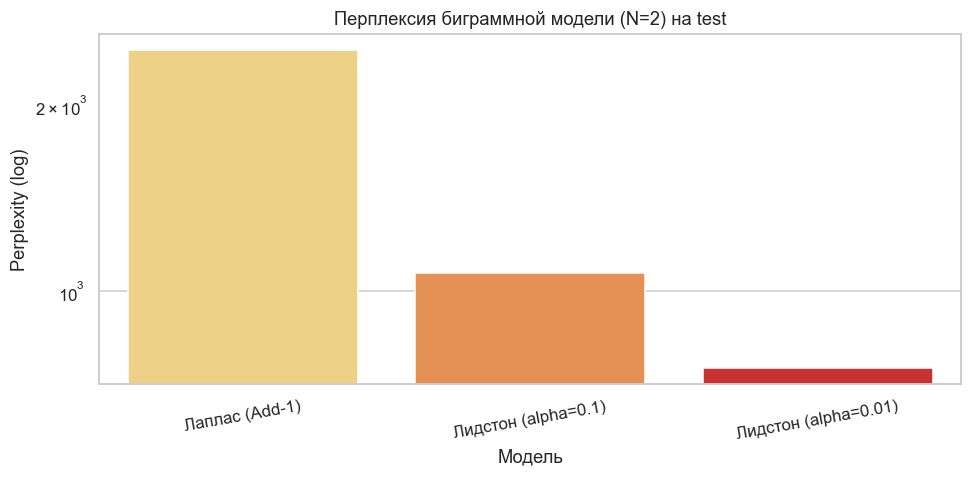

In [66]:
ppl_table = pd.DataFrame({
    "Модель": ["MLE (без сглаживания)", "Лаплас (Add-1)", "Лидстон (alpha=0.1)", "Лидстон (alpha=0.01)"],
    "Перплексия": [ppl_mle, ppl_lap, ppl_lid_01, ppl_lid_001],
})
display(ppl_table.style.hide(axis="index").format({"Перплексия": "{:.2f}"}))

finite = ppl_table[np.isfinite(ppl_table["Перплексия"].astype(float))]
plt.figure(figsize=(9, 4.5))
sns.barplot(data=finite, x="Модель", y="Перплексия", hue="Модель", palette="YlOrRd", legend=False)
plt.yscale("log")
plt.title("Перплексия биграммной модели (N=2) на test")
plt.ylabel("Perplexity (log)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "perplexity.png"), bbox_inches="tight")
plt.show()

Проверим вывод шага 7: на малом корпусе биграммы (меньше контекста, но меньше разреженности) должны давать более низкую перплексию, чем триграммы.

In [67]:
comparison = pd.DataFrame([
    {"Порядок": "N=2 (биграммы)",
     "Без сглаж.": ppl_mle, "Лаплас": ppl_lap,
     "Лидстон 0.1": ppl_lid_01, "Лидстон 0.01": ppl_lid_001},
    {"Порядок": "N=3 (триграммы)",
     "Без сглаж.": perplexity(test_texts, p_mle, order=3), "Лаплас": perplexity(test_texts, p_laplace, order=3),
     "Лидстон 0.1": perplexity(test_texts, lambda c, w: p_lidstone(c, w, 0.1), order=3), "Лидстон 0.01": perplexity(test_texts, lambda c, w: p_lidstone(c, w, 0.01), order=3)},
])

display(comparison.style.hide(axis="index").format("{:.2f}", subset=["Без сглаж.", "Лаплас", "Лидстон 0.1", "Лидстон 0.01"]))

Порядок,Без сглаж.,Лаплас,Лидстон 0.1,Лидстон 0.01
N=2 (биграммы),inf,2452.37,1072.40,751.76
N=3 (триграммы),inf,6214.43,4107.00,2800.35


#### Выводы по шагу 8

1. Без сглаживания перплексия равна бесконечности (и для N=2, и для N=3). По chain rule вероятность текста это произведение условных вероятностей всех N-грамм. Достаточно одной N-граммы, отсутствовавшей в train (а таких на нашем корпусе большинство), чтобы множитель обратился в 0 и обнулил всё произведение. Формально PPL = 2^H, где H = +∞ при log2(0), поэтому MLE-модель на тесте неработоспособна.

2. Лаплас (Add-1) даёт конечную, но завышенную перплексию (2 452.37 для N=2). Он прибавляет единицу к каждой N-грамме и нормирует на Count(c) + V. При большом V = 8 426 добавка съедает заметную долю вероятностной массы и сильно искажает распределение частых событий - это пересглаживание (over-smoothing).

3. Лидстон (Add-alpha) с малым alpha даёт наименьшую перплексию. 1 072.40 при alpha=0.1 и 751.76 при alpha=0.01. При alpha -> 0 оценка стремится к MLE на наблюдаемых N-граммах, но остаётся строго положительной на ненаблюдаемых. Уменьшение alpha с 0.1 до 0.01 снизило PPL в 1.43 раза - это количественно подтверждает, что малый добавок лечит нулевые частоты, минимально искажая частотные оценки. Выбор alpha - компромисс между пересглаживанием (alpha велик) и нулевыми вероятностями (alpha мал).

4. Биграммная модель (N=2) даёт более низкую перплексию, чем триграммная, при любом методе сглаживания (751.76 против 2 800.35 при alpha=0.01). Причина - разреженность: 83.3% триграмм встречаются один раз, поэтому триграммы почти всегда опираются на сглаживание, тогда как биграммы покрывают данные лучше.

**Итог: сглаживание обязательно для корректного расчёта перплексии. На нашем корпусе
оптимальна биграммная модель (N=2) с Лидстоном при малом alpha (0.01).**

### Шаг 9. Генерация текстов на базе марковской цепи

Модель - марковская цепь порядка (N-1): следующее слово зависит только от предыдущих (N-1) слов. 

Генерация:
1. начинаем с токена `<s>`
2. на каждом шаге берём распределение следующего слова из построенной модели
3. если для текущего контекста распределения нет, то откатываемся (backoff) к более низкому порядку (для N=2 — к униграммам)
4. останавливаемся при достижении `</s>` или по максимальной длине
    
Сэмплирование - пропорционально частотам
- temperature < 1 делает текст более жестким (повторяет частые переходы)
- temperature > 1 - более случайным

In [68]:
def sample_from(counter, temperature=1.0):
    """Случайный id из Counter пропорционально частотам (с учётом temperature)"""
    words = np.fromiter(counter.keys(), dtype=np.int64, count=len(counter))
    counts = np.fromiter(counter.values(), dtype=np.float64, count=len(counter))
    probs = counts ** (1.0 / temperature)
    probs /= probs.sum()
    return int(np.random.choice(words, p=probs))

In [69]:
def generate_bigram(max_len=40, temperature=1.0):
    # старт с <s>
    out = [BOS]
    for _ in range(max_len):
        ctx = out[-1]

        # есть биграммный контекст
        if bi_ctx.get(ctx):
            nxt = sample_from(bi_ctx[ctx], temperature)

        # backoff к униграммам
        else:
            nxt = sample_from(uni, temperature)
            
        # дошли до </s> - стоп
        if nxt == EOS:
            break
            
        out.append(nxt)
        
    return " ".join(id2word.get(i, "[UNK]") for i in out if i != BOS)

Сгенерируем 5 текстов

In [70]:
np.random.seed(SEED)
for k in range(1, 6):
    print(f"--- Текст #{k} (N=2) ---")
    print(generate_bigram(max_len=40))
    print()

--- Текст #1 (N=2) ---
i'm unwilling to do.mayday button:a new word alexa commands to make an nvidia shield tv and it in bright sunlight, something that are fine with our older kindle app. if you can be elsewhere to fall out ahead and thinness

--- Текст #2 (N=2) ---
we were great case.

--- Текст #3 (N=2) ---
these for another station or somewhere away even when it silly for the first released. i was perfect for a cover closed captioning functionality for prime member, it's not) so glad that they all of media / reader. focusing and

--- Текст #4 (N=2) ---
i wanted a proprietary device, which allows you have held up with this is no way other than [NUM] the sound quality isn't the new fire hd i gave out there.wdtv: are a general are correct orientation. it's kind of

--- Текст #5 (N=2) ---
great product. it would recommend to listen to leave the video screen quality might decide you are in the like.where i say. but the battery case)display: [NUM] ppi) vs echo always use wireless feature

Сравним с N=3 (триграммы + backoff)

Для триграмм контекст - два предыдущих слова. При его отсутствии откат идёт к биграмме, затем к униграмме.

In [71]:
def generate_trigram(max_len=40, temperature=1.0):
    out = [BOS]
    for _ in range(max_len):
        nxt = None
        if len(out) >= 2 and tri_ctx.get((out[-2], out[-1])):
            nxt = sample_from(tri_ctx[(out[-2], out[-1])], temperature)
        if nxt is None and bi_ctx.get(out[-1]):
            nxt = sample_from(bi_ctx[out[-1]], temperature)
        if nxt is None:
            nxt = sample_from(uni, temperature)
        if nxt == EOS:
            break
        out.append(nxt)
    return " ".join(id2word.get(i, "[UNK]") for i in out if i != BOS)

np.random.seed(SEED)
for k in range(1, 6):
    print(f"--- Текст #{k} (N=3) ---")
    print(generate_trigram(max_len=40))
    print()

--- Текст #1 (N=3) ---
i'm loving my new kindle paperwhite or voyage.for reference, here's a brief comparison of the previous generation fire tablets:--- same display specs as before (amazon says the tablet is amazingly smooth and fast . due to the prime movies and

--- Текст #2 (N=3) ---
we already had a full week with my accent. obviously, this item to replace the one area where last year's model of the fire hd [NUM] and now they want [NUM] , it freezes up and started using it everyday.

--- Текст #3 (N=3) ---
looking for a child and want to do this after i finally got frustrated and returned it.

--- Текст #4 (N=3) ---
this is my first kindle in bed at night to work very well.

--- Текст #5 (N=3) ---
excellent product, awesome color



Сгенерированы 5 текстов марковской цепью с явными границами `<s> … </s>` и остановкой по `</s>` или максимальной длине.

**Грамматическая связность (N=2)** 

Локально фрагменты читаются как английский: корректные служебные слова и короткие словосочетания («great product. it would recommend…», «i wanted a proprietary device»). Однако связность держится 2–4 слова и распадается: появляются слипшиеся токены («do.mayday», «case)display:»), незакрытые скобки и обрывы. Модель воспроизводит локальную статистику пар слов, но не структуру предложения.

**Смысловая адекватность (N=2)**

Низкая: тема дрейфует между устройствами, покрытиями
и ценами, логические связи отсутствуют, встречаются бессмысленные переходы («thinness», «are a general are correct orientation»). Это прямое следствие того, что биграмма учитывает лишь одно предыдущее слово - глобального плана у модели нет.

**Сравнение с N=3** 

Триграммные тексты выглядят связнее и часто короче. Модель уверенно воспроизводит заученные фрагменты («excellent product, awesome color», «this is my first kindle in bed at night to work very well.»). Но это не генерация в строгом смысле, а склейка кусков обучающих отзывов. Кроме того, тексты рано завершаются по `</s>` и сильно копируют train. То есть по перплексии N=3 хуже (шаг 8), а по внешней связности - лучше за счёт буквального запоминания. Обе модели не обладают глобальной смысловой адекватностью.

#### Вывод 
N-граммная марковская модель порождает локально правдоподобный, но
семантически бессвязный текст. Это фундаментальное ограничение. Контекст в 1–2 слова
не позволяет удерживать тему и синтаксис на уровне предложения/абзаца. Для связной
генерации нужны модели с долговременной памятью (RNN, трансформеры). Дополнительно
на качество давит малый размер корпуса. Почти все контексты редки, поэтому модель
часто опирается на откат к униграммам.